# Best Chess Opening: Exploratory Data Analysis
In this EDA our goal is to find statistical truths for beginners, what opening has the best outcome?

## Data Ingestion & "Beginner" Filtering
Since we want to know the best outcomes strictly for beginners to average players, a dataset containing Grandmaster games will heavily skew our insights. So instead we will remove these games and focus on games that were played by beginner to intermidiate players. 

### The Standard Ingestion
In this step, we will run the standard inspection commands to understand how many rows/columns we have, what the data types are, and if there are any missing values (NaNs) we need to worry about.

In [93]:
import pandas as pd 
import numpy as np 

# Loading the csv file into the dataframe
df = pd.read_csv('games.csv')

# Getting initial info from the dataframe
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.3+ MB


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


### Defining the "Beginner" Bracket
In chess, an Elo rating below 1500 is generally considered the beginner-to-intermediate threshold. So we will filter our dataframe so that it only includes matches where both the white_rating and the black_rating are under 1500. We will save this filtered data into a new dataframe variable (e.g., `beginner_games_df`) so we don't permanently alter the original raw data.

In [94]:
# Creating new dataframe, and filtering out any ELOS over 1500
beginner_games_df = df.copy()
beginner_games_df = beginner_games_df[
    (beginner_games_df['white_rating'] < 1500) &
    (beginner_games_df['black_rating'] < 1500)
]

# Sanity Check
beginner_games_df.describe()
beginner_games_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5244 entries, 1 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              5244 non-null   object 
 1   rated           5244 non-null   bool   
 2   created_at      5244 non-null   float64
 3   last_move_at    5244 non-null   float64
 4   turns           5244 non-null   int64  
 5   victory_status  5244 non-null   object 
 6   winner          5244 non-null   object 
 7   increment_code  5244 non-null   object 
 8   white_id        5244 non-null   object 
 9   white_rating    5244 non-null   int64  
 10  black_id        5244 non-null   object 
 11  black_rating    5244 non-null   int64  
 12  moves           5244 non-null   object 
 13  opening_eco     5244 non-null   object 
 14  opening_name    5244 non-null   object 
 15  opening_ply     5244 non-null   int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 660.6+ KB


### The First Metric (First-Mover Advantage)
In chess theory, White is generally thought to have a slight advantage. Let's see if this holds true at the beginner level. We need a baseline to understand the "first-mover advantage" at the beginner level. In order to do this we will calculate the overall win percentage for White, the win percentage for Black, and the percentage of Draws from our newly filtered dataframe.

In [95]:
white_win_pct = round((beginner_games_df['winner'] == 'white').mean() * 100, 2)
black_win_pct = round((beginner_games_df['winner'] == 'black').mean() * 100, 2)
draw_pct = round((beginner_games_df['winner'] == 'draw').mean() * 100, 2)

print(f"White Win Rate: {white_win_pct:.2f}%")
print(f"Black Win Rate: {black_win_pct:.2f}%")
print(f"Draw Rate: {draw_pct:.2f}%")


White Win Rate: 50.67%
Black Win Rate: 45.31%
Draw Rate: 4.02%


## Identifying the Best Beginner Openings
The `games.csv` dataset contains a column called `opening_name` (e.g., "Scandinavian Defense", "Fried Liver Attack", etc.). We need to figure out what beginners are playing, and more importantly, what is actually working for them.

### The Popularity Contest
We shouldn't analyze the win rate of obscure openings, for example an opening that was only played twice. We need some more substantial, we need a statistically significant sample size. In order to do this, we will find the **Top 10** most frequently played openings from our `beginner_games_df`. 

In [96]:
# Getting top ten most played openings
beginner_games_df['opening_name'].value_counts().head(10)

opening_name
Van't Kruijs Opening                             197
Scandinavian Defense                             122
King's Pawn Game: Wayward Queen Attack            98
Scandinavian Defense: Mieses-Kotroc Variation     90
Philidor Defense #2                               85
Sicilian Defense                                  85
King's Pawn Game: Leonardis Variation             83
Scotch Game                                       82
Four Knights Game: Italian Variation              79
Queen's Pawn Game: Chigorin Variation             78
Name: count, dtype: int64

### The Win Rate by Opening 
Just because an opening is popular doesn't mean it's good. We need to find the opening that gives White the highest chance of winning. To do this, we will calculate the White win percentages of each opening. 


In [97]:
openings = [
    "Van't Kruijs Opening",
    "Scandinavian Defense", 
    "King's Pawn Game: Wayward Queen Attack", 
    "Scandinavian Defense: Mieses-Kotroc Variation", 
    "Philidor Defense #2", 
    "Sicilian Defense", 
    "King's Pawn Game: Leonardis Variation", 
    "Scotch Game", 
    "Four Knights Game: Italian Variation", 
    "Queen's Pawn Game: Chigorin Variation"
]

# Creating temp dataframe that only contains top 10 openings played
top_games_df = beginner_games_df[beginner_games_df['opening_name'].isin(openings)]

# Grouping by the opening, and calculating the win percentage of 'White' 
win_rates = top_games_df.groupby('opening_name')['winner'].apply(lambda x: (x == 'white').mean() * 100).round(2)

print('Win Rates')
print(win_rates.sort_values(ascending=False))

Win Rates
opening_name
Scandinavian Defense: Mieses-Kotroc Variation    62.22
Four Knights Game: Italian Variation             62.03
Scotch Game                                      50.00
Philidor Defense #2                              49.41
King's Pawn Game: Leonardis Variation            49.40
Queen's Pawn Game: Chigorin Variation            47.44
Sicilian Defense                                 45.88
Scandinavian Defense                             44.26
King's Pawn Game: Wayward Queen Attack           43.88
Van't Kruijs Opening                             39.09
Name: winner, dtype: float64


## Visualizing the **Best Opening**

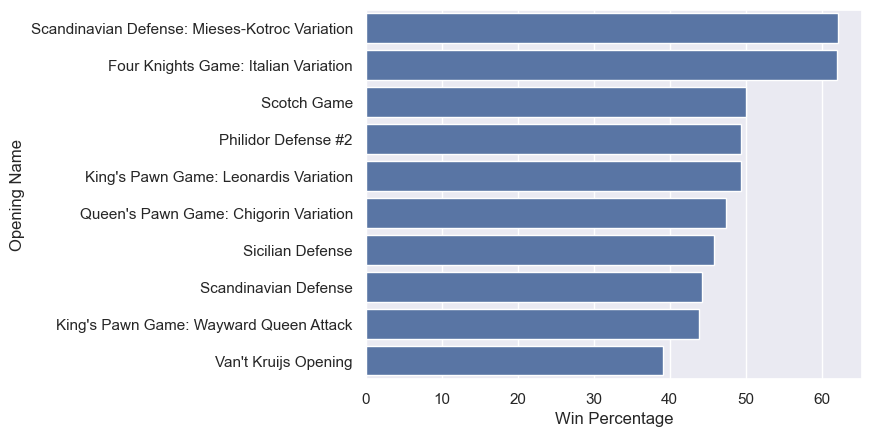

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

# Turning the win_rates series into a dataframe
win_rates_chart = win_rates.reset_index()
win_rates_chart = win_rates_chart.sort_values(by='winner', ascending = False)

ax = sns.barplot(x = 'winner', y = 'opening_name', data = win_rates_chart) 
ax.set(xlabel = 'Win Percentage', ylabel = 'Opening Name')
plt.show()
